In [103]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [ ]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names) # the feature matrix (sepal length/width, petal length/width)
df["species"] = iris.target # the target vector (0=setosa, 1=versicolor, 2=virginica)

In [105]:
print("First 5 Rows")
print(df.head())

First 5 Rows
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  


In [106]:
print("\nDataset Shape")
print(df.shape)


Dataset Shape
(150, 5)


In [107]:
print("\nColumn Names")
print(df.columns)


Column Names
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'species'],
      dtype='object')


In [108]:
print("\nTarget Classes")
print(iris.target_names)


Target Classes
['setosa' 'versicolor' 'virginica']


In [109]:
print("\nDataset Information")
print(df.info())


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
None


In [110]:
print("\nStatistical Summary")
print(df.describe())


Statistical Summary
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)     species  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  


In [111]:
print("Missing Values")
print(df.isnull().sum())

Missing Values
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


In [112]:
print("Dataset Shape:", df.shape)
print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (150, 5)

Duplicate Rows: 1


In [113]:
# Remove duplicate rows
df = df.drop_duplicates()
print("Duplicate Rows After Removal:", df.duplicated().sum())
# Check new dataset shape
print("Dataset Shape:", df.shape)

Duplicate Rows After Removal: 0
Dataset Shape: (149, 5)


In [ ]:
X = df.drop("species", axis=1) 
#Creates the feature matrix X by taking the DataFrame df and dropping the "species" column. 
# axis=1 means "drop a column" leaving behind numeric measurement column
y = df["species"]
#Creates the target/label vector y by selecting just the "species" column, the thing you're trying to predict.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = StandardScaler() #creates the scaler object
X_train = scaler.fit_transform(X_train) # fits (calculates mean/std) only on training data, then transforms it.
X_test = scaler.transform(X_test) # the test set is scaled using the training set's mean/std, never its own.

In [ ]:
model = LogisticRegression(max_iter=200) #creates a logistic regression model object with a maximum of 200 iterations for convergence.
model.fit(X_train, y_train) 
# trains the logistic regression model on the scaled training data, learning the relationship between features and species labels.

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [ ]:
y_pred = model.predict(X_test) # uses the trained model to predict species labels for the scaled test data, generating predicted values.

In [ ]:
print("Logistic Regression Results")

print("Accuracy :", accuracy_score(y_test, y_pred)) 
# Calculates the accuracy of the model by comparing the true labels (y_test) with the predicted labels (y_pred).
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
# Calculates the precision of the model, which is the ratio of true positive predictions to the total predicted positives, averaged across all classes using a weighted approach.
print("Recall   :", recall_score(y_test, y_pred, average="weighted"))
# Calculates the recall of the model, which is the ratio of true positive predictions to the total actual positives, averaged across all classes using a weighted approach.
print("F1-Score :", f1_score(y_test, y_pred, average="weighted"))
# Calculates the F1-score of the model, which is the harmonic mean of precision and recall, providing a single metric that balances both, averaged across all classes using a weighted approach.

Logistic Regression Results
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-Score : 1.0


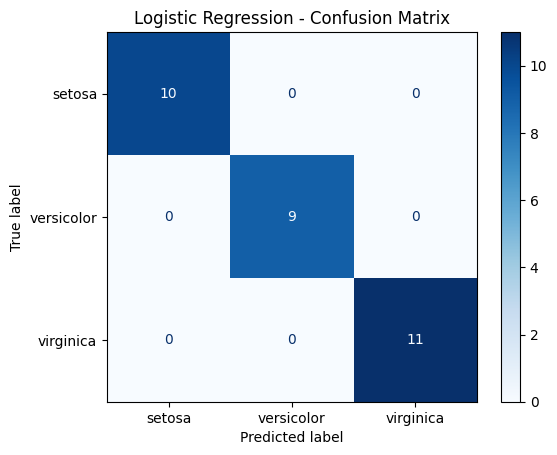

In [ ]:
cm = confusion_matrix(y_test, y_pred) 
# Calculates the confusion matrix, which is a table that summarizes the performance of the classification model 
# by showing the counts of true positive, true negative, false positive, and false negative predictions.

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot(cmap="Blues")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [ ]:
print("Sample Predictions")
# Displays the actual and predicted species labels for the first 10 test samples.
for i in range(10):
    print(
        "Actual:", iris.target_names[y_test.iloc[i]],
        "| Predicted:", iris.target_names[y_pred[i]]
    )

Sample Predictions
Actual: versicolor | Predicted: versicolor
Actual: setosa | Predicted: setosa
Actual: virginica | Predicted: virginica
Actual: versicolor | Predicted: versicolor
Actual: versicolor | Predicted: versicolor
Actual: setosa | Predicted: setosa
Actual: versicolor | Predicted: versicolor
Actual: virginica | Predicted: virginica
Actual: versicolor | Predicted: versicolor
Actual: versicolor | Predicted: versicolor


In [ ]:
dec_tree_model = DecisionTreeClassifier(random_state=42)
# Creates a Decision Tree Classifier model object with a specified random state for reproducibility.
dec_tree_model.fit(X_train, y_train) # trains the decision tree model on the training data, learning the relationship between features and species labels.

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [ ]:
dec_tree_y_pred = dt_model.predict(X_test) 
# uses the trained decision tree model to predict species labels for the scaled test data, generating predicted values.

In [123]:
print("Decision Tree Results")

print("Accuracy :", accuracy_score(y_test, dec_tree_y_pred))
print("Precision:", precision_score(y_test, dec_tree_y_pred, average="weighted"))
print("Recall   :", recall_score(y_test, dec_tree_y_pred, average="weighted"))
print("F1-Score :", f1_score(y_test, dec_tree_y_pred, average="weighted"))

Decision Tree Results
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-Score : 1.0


[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


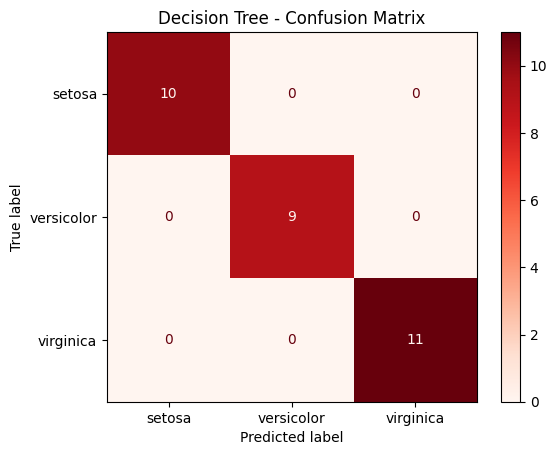

In [124]:
cm = confusion_matrix(y_test, dec_tree_y_pred)
print(cm)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)
disp.plot(cmap="Reds")
plt.title("Decision Tree - Confusion Matrix")
plt.show()